Saving iris.csv to iris.csv
First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   peta

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


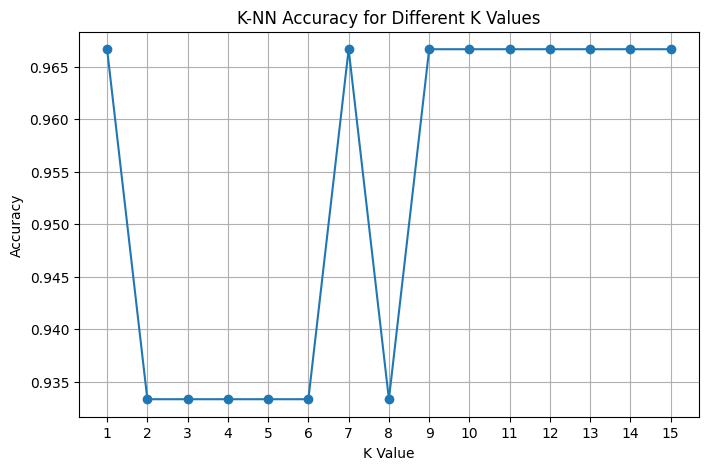

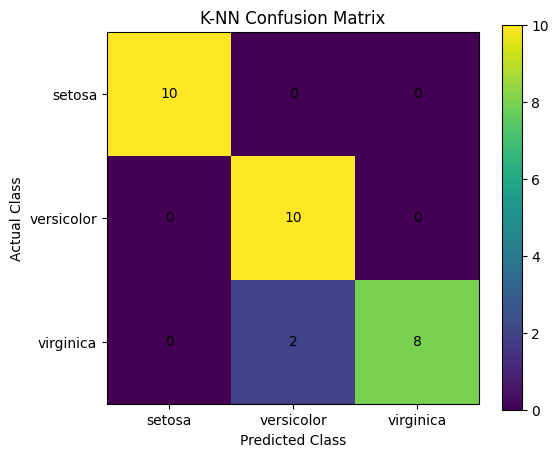


Prediction Results:
    Actual  Predicted Actual_Class Predicted_Class
0        0          0       setosa          setosa
1        2          2    virginica       virginica
2        1          1   versicolor      versicolor
3        1          1   versicolor      versicolor
4        0          0       setosa          setosa
5        1          1   versicolor      versicolor
6        0          0       setosa          setosa
7        0          0       setosa          setosa
8        2          2    virginica       virginica
9        1          1   versicolor      versicolor
10       2          2    virginica       virginica
11       2          2    virginica       virginica
12       2          2    virginica       virginica
13       1          1   versicolor      versicolor
14       0          0       setosa          setosa
15       0          0       setosa          setosa
16       0          0       setosa          setosa
17       1          1   versicolor      versicolor
18       1

In [ ]:
# K-NEAREST NEIGHBORS (K-NN) CLASSIFICATION

# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from google.colab import files

uploaded = files.upload()
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target/class column
df["target"] = iris.target

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nClass Names:")
print(iris.target_names)

# 3. Select Features and Target

X = df[iris.feature_names]
y = df["target"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# 4. Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# 5. Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

# 6. Create K-NN Model

k = 5

knn = KNeighborsClassifier(
    n_neighbors=k,
    weights="uniform",
    metric="euclidean"
)

# 7. Train the Model

knn.fit(X_train_scaled, y_train)

print("\nK-NN model trained successfully.")

# ---------------------------------------------------------
# 8. Predict Test Data
# ---------------------------------------------------------

y_pred = knn.predict(X_test_scaled)

print("\nPredicted Classes:")
print(y_pred)

print("\nActual Classes:")
print(y_test.to_numpy())

# ---------------------------------------------------------
# 9. Predict New/Test Data
# ---------------------------------------------------------

new_data = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.0, 5.2, 2.3],
    [5.9, 3.0, 4.2, 1.5]
])

# Scale new data
new_data_scaled = scaler.transform(new_data)

# Predict
new_predictions = knn.predict(new_data_scaled)

print("\nPredictions for New Test Data:")

for i, prediction in enumerate(new_predictions):
    print(
        "Test Data", i + 1,
        "=>",
        iris.target_names[prediction]
    )

# ---------------------------------------------------------
# 10. Calculate Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# ---------------------------------------------------------
# 11. Calculate Error Rate
# ---------------------------------------------------------

error_rate = 1 - accuracy

print("Error Rate:", error_rate)
print("Error Percentage:", error_rate * 100, "%")

# ---------------------------------------------------------
# 12. Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ---------------------------------------------------------
# 13. Classification Report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

# ---------------------------------------------------------
# 14. Test Different K Values
# ---------------------------------------------------------

k_values = range(1, 16)
accuracy_values = []

for k_value in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k_value,
        metric="euclidean"
    )

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, prediction)

    accuracy_values.append(acc)

print("\nAccuracy for Different K Values:")

for k_value, acc in zip(k_values, accuracy_values):
    print(
        "K =", k_value,
        "Accuracy =", round(acc * 100, 2), "%"
    )

# ---------------------------------------------------------
# 15. Find Best K
# ---------------------------------------------------------

best_k = k_values[np.argmax(accuracy_values)]
best_accuracy = max(accuracy_values)

print("\nBest K Value:", best_k)
print("Best Accuracy:", best_accuracy * 100, "%")

# ---------------------------------------------------------
# 16. Accuracy vs K Graph
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_values,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K-NN Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

# ---------------------------------------------------------
# 17. Confusion Matrix Visualization
# ---------------------------------------------------------

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("K-NN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(iris.target_names)),
    iris.target_names
)

plt.yticks(
    range(len(iris.target_names)),
    iris.target_names
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

# ---------------------------------------------------------
# 18. Display Prediction Results
# ---------------------------------------------------------

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result["Actual_Class"] = result["Actual"].apply(
    lambda x: iris.target_names[x]
)

result["Predicted_Class"] = result["Predicted"].apply(
    lambda x: iris.target_names[x]
)

print("\nPrediction Results:")
print(result)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Shape:
(20640, 9)

Dataset Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

Features:
   M

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Results for Different K Values:
K = 1 | R² = 0.4895 | RMSE = 0.8179
K = 2 | R² = 0.601 | RMSE = 0.7231
K = 3 | R² = 0.6439 | RMSE = 0.6831
K = 4 | R² = 0.6586 | RMSE = 0.6689
K = 5 | R² = 0.67 | RMSE = 0.6576
K = 6 | R² = 0.6725 | RMSE = 0.6551
K = 7 | R² = 0.6731 | RMSE = 0.6545
K = 8 | R² = 0.676 | RMSE = 0.6516
K = 9 | R² = 0.676 | RMSE = 0.6516
K = 10 | R² = 0.6783 | RMSE = 0.6493
K = 11 | R² = 0.6806 | RMSE = 0.647
K = 12 | R² = 0.6809 | RMSE = 0.6467
K = 13 | R² = 0.6823 | RMSE = 0.6452
K = 14 | R² = 0.6811 | RMSE = 0.6464
K = 15 | R² = 0.6804 | RMSE = 0.6471

Best K Value: 13
Best R² Score: 0.6823


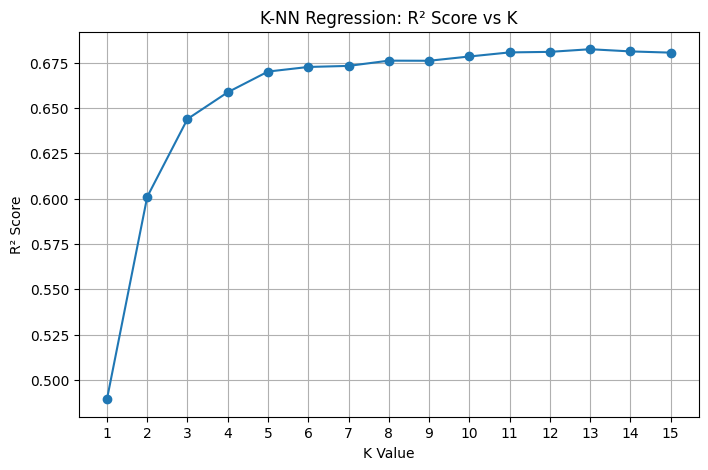

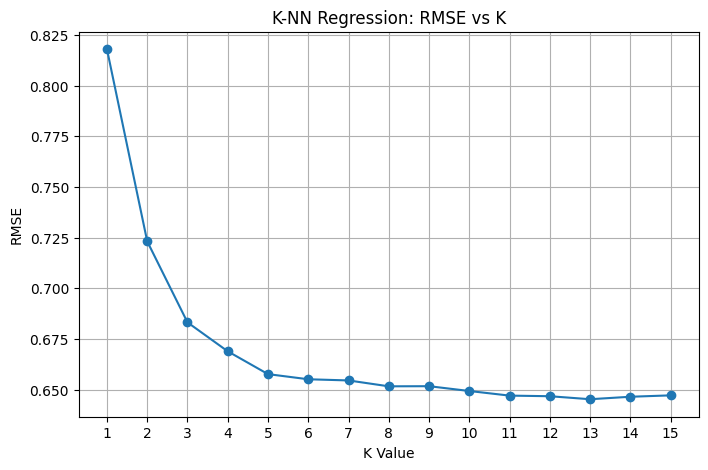

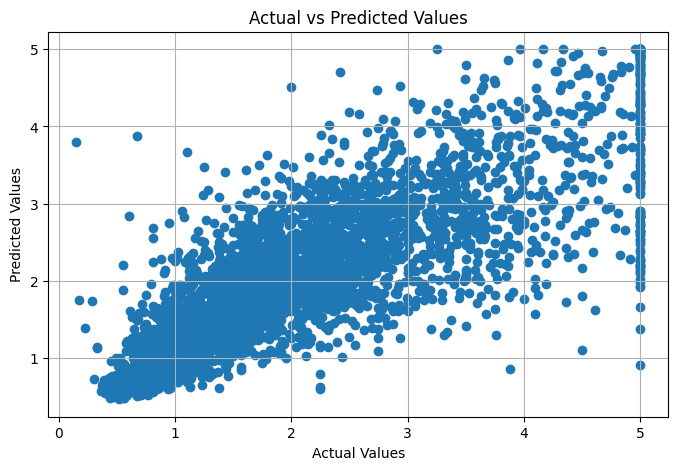


Prediction Results:


,Actual Value,Predicted Value,Error,Absolute Error
0,0.47700,0.498800,-0.021800,0.021800
1,0.45800,0.764600,-0.306600,0.306600
2,5.00001,4.750006,0.250004,0.250004
3,2.18600,2.876600,-0.690600,0.690600
4,2.78000,2.726200,0.053800,0.053800
5,1.58700,1.778600,-0.191600,0.191600
6,1.98200,2.718200,-0.736200,0.736200
7,1.57500,1.924600,-0.349600,0.349600
8,3.40000,2.031400,1.368600,1.368600
9,4.46600,4.955608,-0.489608,0.489608


In [ ]:
# =========================================================
# K-NEAREST NEIGHBORS (K-NN) REGRESSION
# =========================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# 2. Load Dataset
# =========================================================

housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Target"] = housing.target

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# 3. Select Features and Target
# =========================================================

X = df.drop("Target", axis=1)
y = df["Target"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# =========================================================
# 4. Split Dataset
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# =========================================================
# 5. Feature Scaling
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

# =========================================================
# 6. Create K-NN Regression Model
# =========================================================

k = 5

knn = KNeighborsRegressor(
    n_neighbors=k,
    weights="uniform",
    metric="euclidean"
)

# =========================================================
# 7. Train Model
# =========================================================

knn.fit(X_train_scaled, y_train)

print("\nK-NN Regression model trained successfully.")

# =========================================================
# 8. Predict Test Data
# =========================================================

y_pred = knn.predict(X_test_scaled)

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

# =========================================================
# 9. Predict New/Test Data
# =========================================================

new_data = np.array([
    X.iloc[0].values,
    X.iloc[10].values,
    X.iloc[20].values
])

new_data_scaled = scaler.transform(new_data)

new_predictions = knn.predict(new_data_scaled)

print("\nPredictions for New Data:")

for i, prediction in enumerate(new_predictions):
    print(
        "Test Data", i + 1,
        "Predicted Value =", prediction
    )

# =========================================================
# 10. Mean Absolute Error (MAE)
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

print("\nMean Absolute Error (MAE):", mae)

# =========================================================
# 11. Mean Squared Error (MSE)
# =========================================================

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

# =========================================================
# 12. Root Mean Squared Error (RMSE)
# =========================================================

rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

# =========================================================
# 13. R² Score
# =========================================================

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

# =========================================================
# 14. Test Different K Values
# =========================================================

k_values = range(1, 16)

r2_values = []
rmse_values = []

for k_value in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k_value,
        weights="uniform",
        metric="euclidean"
    )

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    r2 = r2_score(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    r2_values.append(r2)
    rmse_values.append(rmse)

# =========================================================
# 15. Display K Results
# =========================================================

print("\nResults for Different K Values:")

for k_value, r2, rmse in zip(
    k_values,
    r2_values,
    rmse_values
):

    print(
        "K =", k_value,
        "| R² =", round(r2, 4),
        "| RMSE =", round(rmse, 4)
    )

# =========================================================
# 16. Find Best K
# =========================================================

best_k = k_values[np.argmax(r2_values)]

best_r2 = max(r2_values)

print("\nBest K Value:", best_k)

print(
    "Best R² Score:",
    round(best_r2, 4)
)

# =========================================================
# 17. R² vs K Graph
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    r2_values,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("R² Score")

plt.title("K-NN Regression: R² Score vs K")

plt.xticks(list(k_values))

plt.grid(True)

plt.show()

# =========================================================
# 18. RMSE vs K Graph
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    rmse_values,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("RMSE")

plt.title("K-NN Regression: RMSE vs K")

plt.xticks(list(k_values))

plt.grid(True)

plt.show()

# =========================================================
# 19. Actual vs Predicted Graph
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

# =========================================================
# 20. Prediction Results Table
# =========================================================

result = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred
})

result["Error"] = (
    result["Actual Value"] -
    result["Predicted Value"]
)

result["Absolute Error"] = (
    abs(result["Error"])
)

print("\nPrediction Results:")

display(result.head(20))